# **Analisis Komparatif Kinerja SVM dan Bi-LSTM dalam Deteksi Keluhan Server pada Ulasan Aplikasi KAI Access.**
### Kelompok 8 (2024 E)
Ananda Keissa Az Zahra (24031554051), Laili Nurrohmatul Fadhila Z. (24031554093), Eka Putri Maharani (24031554121)

In [1]:
# !gdown --folder "https://drive.google.com/drive/folders/13nOgKhvT3yveYKYpObapApVLyMjo3JeB?usp=sharing"

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
!pip install nlpaug
!pip install fasttext
!pip install gensim
!pip install optuna
!pip install tensorflow
!pip install transformers
!pip install torch

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached fasttext-0.9.3.tar.gz (73 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
Failed to build fasttext


  error: subprocess-exited-with-error
  
  × Building wheel for fasttext (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [48 lines of output]
      C:\Users\ASUS\AppData\Local\Temp\pip-build-env-3132a04j\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
              (Affected: fasttext).
      
              Available configuration options are listed in:
              https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
      
              This deprecation is overdue, please update your project and remove deprec

Defaulting to user installation because normal site-packages is not writeable


...


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import torch
from transformers import AutoTokenizer, AutoModel
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Bidirectional, LSTM, Dense, Dropout,
                                      Embedding, Input, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
import nlpaug.augmenter.word as naw
import nltk

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **SCRAPING KAI ACCESS**

In [5]:
# !pip install google-play-scraper

In [6]:
# from google_play_scraper import app, reviews
# import pandas as pd
# import datetime

In [7]:
# from google_play_scraper.utils.request import get
# from google_play_scraper import reviews, Sort

# app_id = 'com.kai.kaiticketing'

# def get_reviews(app_id, lang= 'id', count= 5000, sort=Sort.NEWEST, filter_score_with=None, filter_device_with=None, continuation_token=None):
#   try:
#       result, continuation_token = reviews(
#           app_id,
#           lang=lang,
#           country= 'id',
#           count=count,
#           sort=sort,
#           filter_score_with=filter_score_with,
#           filter_device_with=filter_device_with,
#           continuation_token=continuation_token
#       )

#       return result, continuation_token
#   except Exception as e:
#       print("Error:", e)
#       return None, None

# reviews_raw, continuation_token = get_reviews(app_id)

# if reviews_raw is not None:
#   # Filter reviews for length (e.g., content length > 20 characters)
#   min_content_length = 20
#   reviews = [r for r in reviews_raw if len(r.get('content', '')) > min_content_length]

#   print("Jumlah ulasan setelah filter:", len(reviews))
#   if len(reviews) > 0:
#     print("Contoh ulasan panjang:")
#     print(reviews[0])
#   else:
#     print("Tidak ada ulasan panjang yang ditemukan.")
# else:
#   print("Tidak ada ulasan yang ditemukan.")

In [8]:
# import csv

# def export_to_csv(reviews, filename= 'scraping_ulasan_kaiaccess.csv'):
#   if reviews:
#     fieldnames = ['Review ID', 'Username', 'Rating', 'Review Text', 'Date']

#     with open(filename, mode='w', newline='', encoding='utf-8') as csv_file:
#       writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
#       writer.writeheader()

#       for review in reviews:
#         writer.writerow({
#             'Review ID': review['reviewId'],
#             'Username': review['userName'],
#             'Rating': review['score'],
#             'Review Text': review['content'],
#             'Date': review['at']
#         })

# export_to_csv(reviews)

In [9]:
# df_kai = pd.read_csv('scraping_ulasan_kaiaccess.csv')
# df_kai

## **Hasil Labelling Manual**

Sumber Data: Google Play Store (Aplikasi: Access by KAI / com.kai.kaiticketing).

Waktu Pengambilan: [2026-05-06].

In [10]:
import pandas as pd
df = pd.read_csv('scrapping kai access - scraping_ulasan_kaiaccess.csv')
df

,Review ID,Username,Rating,Review Text,Date,label
0,9bcf9ba5-0774-44fb-94fa-7715467e62ed,Pengguna Google,3,"enggak bisa pesen tiket, jadwal kereta juga ti...",2026-05-06 11:34:01,1
1,4e26e5ad-402e-47c5-9dd0-3b3891f0bd5a,Pengguna Google,5,pesan kereta lokal ud d ketik tujuan nya g kel...,2026-05-06 11:25:44,1
2,b30c9366-0177-4213-b2b0-99129df3e65f,Pengguna Google,1,ngapain sih verifikasi otp lama banget,2026-05-06 9:43:23,1
3,6afc5170-edc4-4e5a-884e-039607719da5,Pengguna Google,5,"kapan aplikasinya bisa di gunakan kembali?, sa...",2026-05-06 9:33:50,1
4,3ce6a560-414b-4747-b6f8-d74c6fe19e5c,Pengguna Google,1,Jujur untuk pengguna pembaca layar aplikasi in...,2026-05-06 9:08:17,0
...,...,...,...,...,...,...
3175,27bf8c60-ec51-4324-9cb3-7a27572418f6,Ade Robiyanton,4,Tidak di bisa di buka.. Ada apa KAI??,2025-12-22 13:18:01,1
3176,9e2946ef-1292-4918-a524-ee2b30cc3ef1,Fendzy,1,"mark up harga gila gilaan di hari besar, kek kon",2025-12-22 12:50:26,0
3177,4ca9e27b-75cc-45fa-9696-e1a7ff06d11b,Alfiana Alfi,5,kai akses kenapa tidak ada di tab android lagi...,2025-12-22 11:34:05,0
3178,6cfc90d7-2b45-4709-9729-0ccc3bb61bf8,putri Ayu pengukir,4,Selama saya menggunakan yeah g masalah..,2025-12-22 11:31:20,0


In [11]:
df = df[['Date', 'Review Text', 'label']].copy()

## **Preprocessing**

Case Folding & Cleansing

In [12]:
import pandas as pd
import re

def tahap1_cleansing(text):
    # Case Folding
    text = str(text).lower()

    # Cleansing
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleansing'] = df['Review Text'].apply(tahap1_cleansing)

Normalization

In [13]:
df_kamus = pd.read_csv('kata normalisasi.csv')

df_kamus_cleaned = df_kamus.dropna(subset=['baku']).copy()
kamus_dict = dict(zip(df_kamus_cleaned['tidak baku'], df_kamus_cleaned['baku']))

def normalisasi_teks(teks):
    teks = str(teks)
    kata_kata = teks.split()
    kata_normal = [kamus_dict.get(kata, kata) for kata in kata_kata]
    return ' '.join(kata_normal)

df['baku'] = df['cleansing'].apply(normalisasi_teks)

Stopword Removal

In [14]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stopword_list = stopwords.words('indonesian')

kata_penting = ['tidak', 'bukan', 'belum', 'kurang', 'jangan', 'bisa', 'lama', 'baru', 'keluar', 'gagal', 'batal']
for kata in kata_penting:
    if kata in stopword_list:
        stopword_list.remove(kata)

stopword_list.extend(['sih', 'nya', 'kan', 'dong', 'juga', 'aja', 'yang'])

def tahap3_stopword(text):
    words = text.split()
    filtered_words = [w for w in words if w not in stopword_list]
    text_bersih = ' '.join(filtered_words)
    return text_bersih

df['stopwords'] = df['baku'].apply(tahap3_stopword)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Stemming

In [15]:
!pip install Sastrawi

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def tahap4_stemming(text):
    return stemmer.stem(text)

df['stemming'] = df['stopwords'].apply(tahap4_stemming)
df

,Date,Review Text,label,cleansing,baku,stopwords,stemming
0,2026-05-06 11:34:01,"enggak bisa pesen tiket, jadwal kereta juga ti...",1,enggak bisa pesen tiket jadwal kereta juga tid...,tidak bisa pesan tiket jadwal kereta juga tida...,tidak bisa pesan tiket jadwal kereta tidak mun...,tidak bisa pesan tiket jadwal kereta tidak mun...
1,2026-05-06 11:25:44,pesan kereta lokal ud d ketik tujuan nya g kel...,1,pesan kereta lokal ud d ketik tujuan nya g kel...,pesan kereta lokal sudah di ketik tujuan nya t...,pesan kereta lokal ketik tujuan tidak keluar t...,pesan kereta lokal ketik tuju tidak keluar tiket
2,2026-05-06 9:43:23,ngapain sih verifikasi otp lama banget,1,ngapain sih verifikasi otp lama banget,kenapa sih verifikasi otp lama sekali,verifikasi otp lama,verifikasi otp lama
3,2026-05-06 9:33:50,"kapan aplikasinya bisa di gunakan kembali?, sa...",1,kapan aplikasinya bisa di gunakan kembali saya...,kapan aplikasinya bisa di gunakan kembali saya...,aplikasinya bisa pesan tiket gagal,aplikasi bisa pesan tiket gagal
4,2026-05-06 9:08:17,Jujur untuk pengguna pembaca layar aplikasi in...,0,jujur untuk pengguna pembaca layar aplikasi in...,jujur untuk pengguna pembaca layar aplikasi in...,jujur pengguna pembaca layar aplikasi update t...,jujur guna baca layar aplikasi update tidak ka...
...,...,...,...,...,...,...,...
3175,2025-12-22 13:18:01,Tidak di bisa di buka.. Ada apa KAI??,1,tidak di bisa di buka ada apa kai,tidak di bisa di buka ada apa kai,tidak bisa buka kai,tidak bisa buka kai
3176,2025-12-22 12:50:26,"mark up harga gila gilaan di hari besar, kek kon",0,mark up harga gila gilaan di hari besar kek kon,mark up harga gila gilaan di hari besar bagaim...,mark up harga gila gilaan kon,mark up harga gila gila kon
3177,2025-12-22 11:34:05,kai akses kenapa tidak ada di tab android lagi...,0,kai akses kenapa tidak ada di tab android lagi...,kai akses kenapa tidak ada di tab android lagi...,kai akses tidak tab android,kai akses tidak tab android
3178,2025-12-22 11:31:20,Selama saya menggunakan yeah g masalah..,0,selama saya menggunakan yeah g masalah,selama saya menggunakan yeah tidak masalah,yeah tidak,yeah tidak


In [17]:
df['Date'] = pd.to_datetime(df['Date'])

In [18]:
df.to_csv('hasil_preprocessing.csv', index=False)

## **EDA**

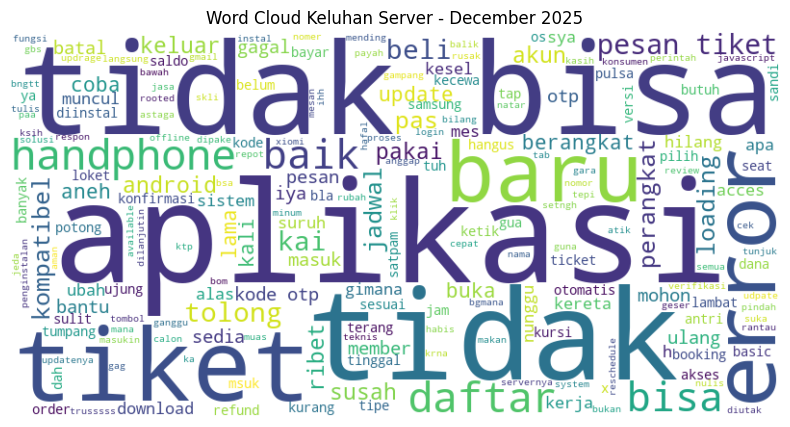

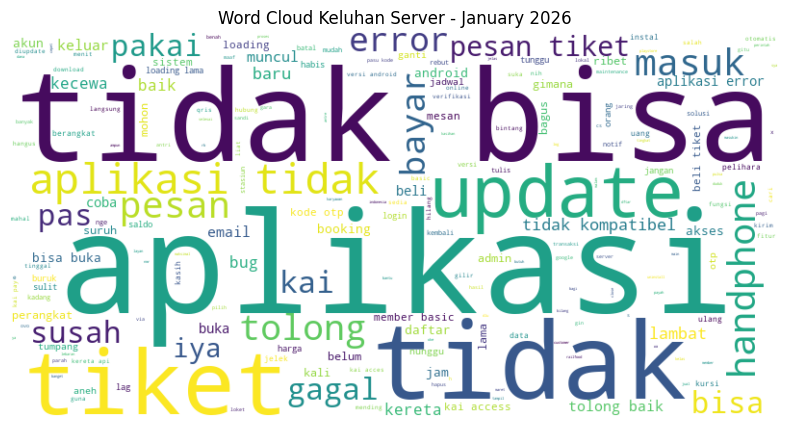

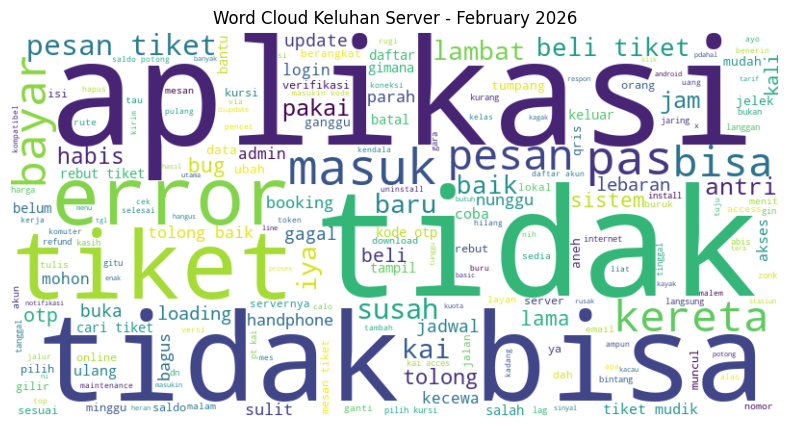

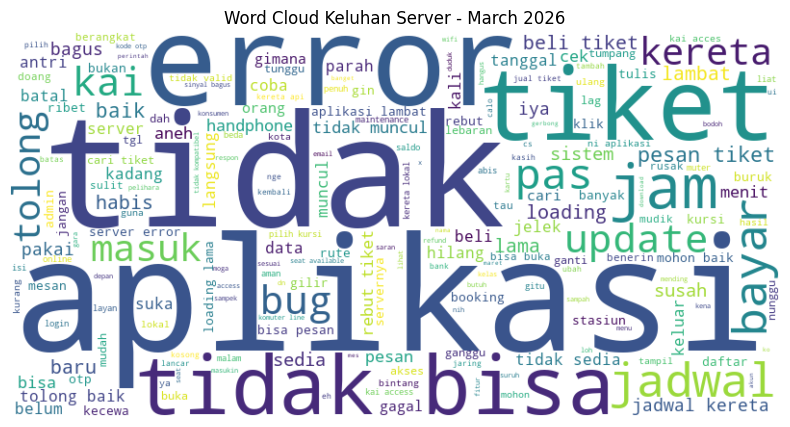

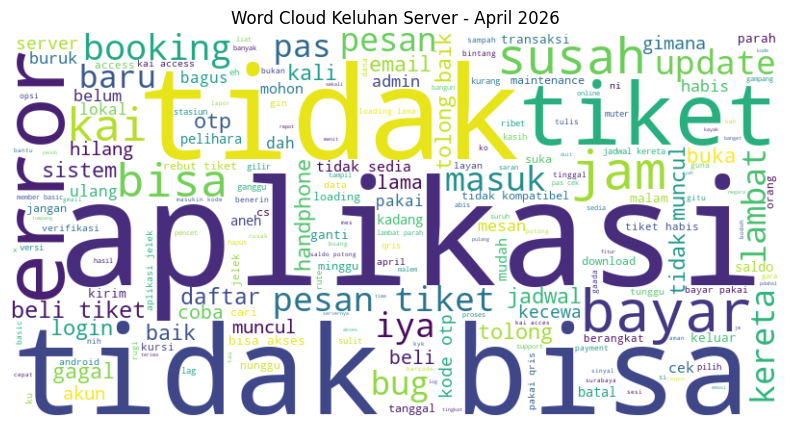

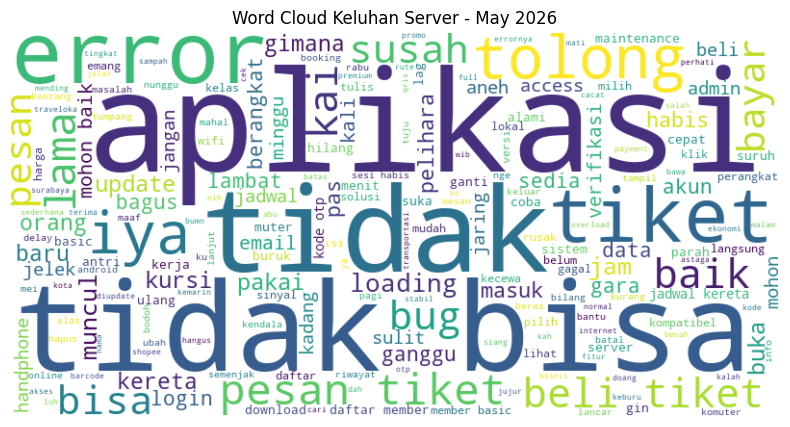

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df_negative_reviews = df[df['label'] == 1].copy()
df_negative_reviews['year_month'] = df_negative_reviews['Date'].dt.to_period('M')
monthly_negative_text = df_negative_reviews.groupby('year_month')['stemming'].apply(lambda x: ' '.join(x))
for month_period, text in monthly_negative_text.items():
    if len(text) > 0:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud Keluhan Server - {month_period.strftime("%B %Y")}')
        plt.show()
    else:
        print(f"Tidak ada ulasan negatif untuk {month_period.strftime("%B %Y")}.")

df.drop(columns=['year_month'], errors='ignore', inplace=True)


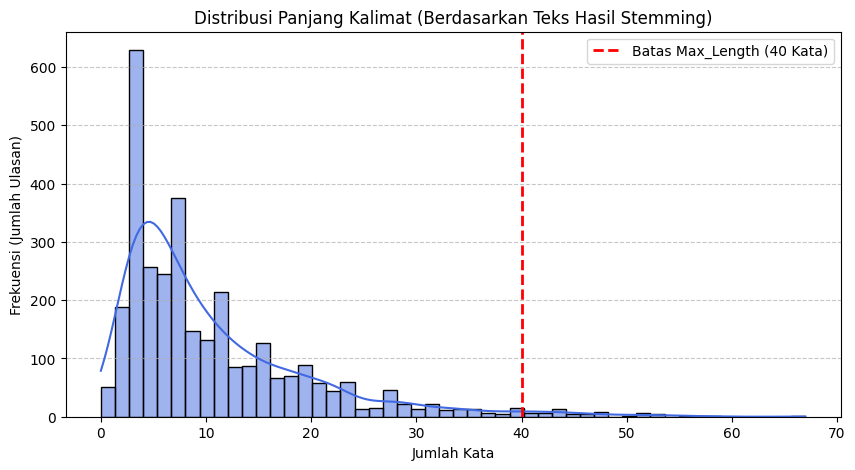

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df['word_count'] = df['stemming'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='word_count', bins=50, kde=True, color='royalblue')

plt.axvline(x=40, color='red', linestyle='--', linewidth=2, label='Batas Max_Length (40 Kata)')
plt.title('Distribusi Panjang Kalimat (Berdasarkan Teks Hasil Stemming)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi (Jumlah Ulasan)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

df.drop(columns=['word_count'], errors='ignore', inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14680\297675856.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#4CAF50', '#F44336'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14680\297675856.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-Keluhan Server (0)', 'Keluhan Server (1)'])


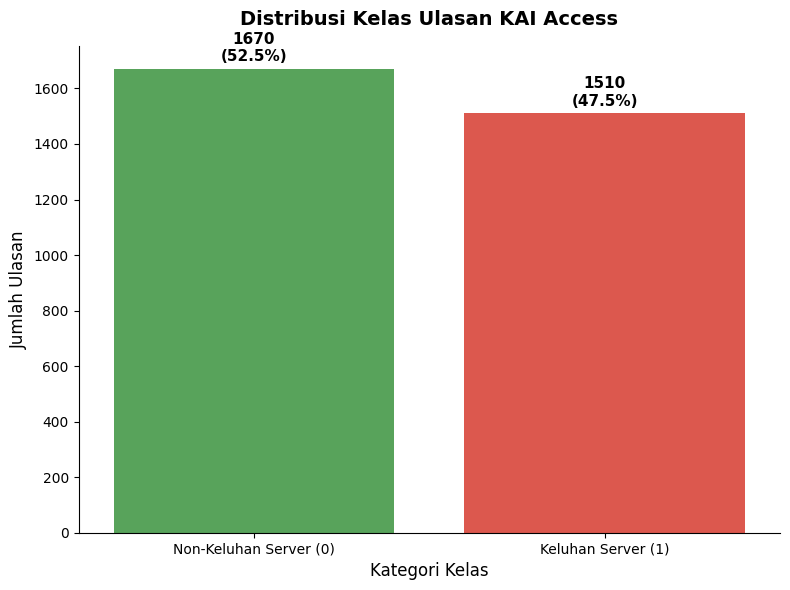

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='label', palette=['#4CAF50', '#F44336'])
ax.set_xticklabels(['Non-Keluhan Server (0)', 'Keluhan Server (1)'])

plt.title('Distribusi Kelas Ulasan KAI Access', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Kelas', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

total_data = len(df)
for p in ax.patches:
    jumlah = int(p.get_height())
    persentase = f'({100 * jumlah / total_data:.1f}%)'
    teks_anotasi = f'{jumlah}\n{persentase}'
    
    ax.annotate(teks_anotasi, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 15), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('distribusi_kelas_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("Distribusi kelas 'label':")
print(df['label'].value_counts())
print("\nPersentase distribusi kelas 'label':")
print(df['label'].value_counts(normalize=True) * 100)

Distribusi kelas 'label':
label
0    1670
1    1510
Name: count, dtype: int64

Persentase distribusi kelas 'label':
label
0    52.515723
1    47.484277
Name: proportion, dtype: float64


## **Text Augmentation**

In [25]:
import warnings
import numpy as np
import pandas as pd
import nltk
import tensorflow as tf


nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

In [29]:
# Distribusi data awal
print(f"Total data: {len(df)}")
print(f"\nDistribusi label:")
print(df['label'].value_counts())
print(f"\nContoh data:")
print(df.head(3))

def augment_teks(teks, n_augment=1):
    hasil = []
    words = teks.split()

    if len(words) < 3:
        return [teks]

    for _ in range(n_augment):
        # Operasi 1: Synonym Replacement
        sinonim_id = {
            'bagus': ['baik', 'mantap', 'oke', 'keren'],
            'jelek': ['buruk', 'parah', 'tidak bagus', 'kurang'],
            'lambat': ['pelan', 'lama', 'lemot', 'tidak cepat'],
            'cepat': ['kilat', 'sigap', 'responsif', 'gesit'],
            'error': ['galat', 'bermasalah', 'rusak', 'eror'],
            'crash': ['force close', 'berhenti', 'mati', 'keluar sendiri'],
            'aplikasi': ['app', 'apk', 'program', 'sistem'],
            'susah': ['sulit', 'repot', 'tidak mudah', 'rumit'],
            'mudah': ['gampang', 'simpel', 'tidak sulit', 'praktis'],
            'senang': ['puas', 'bahagia', 'suka', 'happy'],
        }
        words_copy = words.copy()
        for i, word in enumerate(words_copy):
            if word.lower() in sinonim_id and np.random.rand() < 0.3:
                words_copy[i] = np.random.choice(sinonim_id[word.lower()])
                break

        # Operasi 2: Random Swap
        if len(words_copy) >= 4 and np.random.rand() < 0.5:
            i, j = np.random.choice(len(words_copy), 2, replace=False)
            words_copy[i], words_copy[j] = words_copy[j], words_copy[i]

        # Operasi 3: Random Deletion
        words_final = [w for w in words_copy if np.random.rand() > 0.1]
        if len(words_final) == 0:
            words_final = words_copy

        hasil.append(' '.join(words_final))

    return hasil


augmented_stemming = []
augmented_baku     = []
augmented_labels   = []

for _, row in df.iterrows():
    teks_stem  = row['stemming']   
    teks_baku  = row['baku']       
    label      = row['label']

    augmented_stemming.append(teks_stem)
    augmented_baku.append(teks_baku)
    augmented_labels.append(label)

    for aug_stem in augment_teks(teks_stem, n_augment=1):
        augmented_stemming.append(aug_stem)
        augmented_baku.append(teks_baku)   
        augmented_labels.append(label)

df_aug = pd.DataFrame({
    'stemming': augmented_stemming,
    'baku':     augmented_baku,
    'label':    augmented_labels
})

print(f"Data sebelum augmentasi : {len(df)}")
print(f"Data setelah augmentasi : {len(df_aug)}")
print(f"\nDistribusi label setelah augmentasi:")
print(df_aug['label'].value_counts())

print(f"\nVerifikasi sinkronisasi kolom:")
print(f"  Jumlah baris stemming : {len(df_aug['stemming'])}")
print(f"  Jumlah baris baku     : {len(df_aug['baku'])}")
print(f"  Sinkron               : {len(df_aug['stemming']) == len(df_aug['baku'])} ✅")

# Contoh hasil augmentasi
print(f"\nContoh augmentasi (baris 0 asli vs hasil augmentasinya):")
print(f"  stemming ASLI : {df['stemming'].iloc[0]}")
print(f"  stemming AUG  : {df_aug['stemming'].iloc[1]}")   
print(f"  baku ASLI     : {df['baku'].iloc[0]}")
print(f"  baku AUG      : {df_aug['baku'].iloc[1]}")        

Total data: 3180

Distribusi label:
label
0    1670
1    1510
Name: count, dtype: int64

Contoh data:
                 Date                                        Review Text  \
0 2026-05-06 11:34:01  enggak bisa pesen tiket, jadwal kereta juga ti...   
1 2026-05-06 11:25:44  pesan kereta lokal ud d ketik tujuan nya g kel...   
2 2026-05-06 09:43:23             ngapain sih verifikasi otp lama banget   

   label                                          cleansing  \
0      1  enggak bisa pesen tiket jadwal kereta juga tid...   
1      1  pesan kereta lokal ud d ketik tujuan nya g kel...   
2      1             ngapain sih verifikasi otp lama banget   

                                                baku  \
0  tidak bisa pesan tiket jadwal kereta juga tida...   
1  pesan kereta lokal sudah di ketik tujuan nya t...   
2              kenapa sih verifikasi otp lama sekali   

                                           stopwords  \
0  tidak bisa pesan tiket jadwal kereta tidak mun...   
1  

## **Split Data**

In [30]:
from sklearn.model_selection import train_test_split

df_aug = df_aug.reset_index(drop=True)

# X FastText & SVM & BiLSTM 
X_stem = df_aug['stemming'].astype(str).tolist()

# X IndoBERT
X_baku = df_aug['baku'].astype(str).tolist()

y = df_aug['label'].astype(int).tolist()

# Split untuk FastText, SVM, BiLSTM
X_train, X_temp, y_train, y_temp = train_test_split(
    X_stem, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Split untuk IndoBERT
X_train_baku, X_temp_baku, _, _ = train_test_split(
    X_baku, y, test_size=0.30, random_state=42, stratify=y
)
X_val_baku, X_test_baku, _, _ = train_test_split(
    X_temp_baku, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {len(X_train)} sampel")
print(f"Val   : {len(X_val)} sampel")
print(f"Test  : {len(X_test)} sampel")
print()
print(f"  y_train sama di kedua split: {y_train == y_train}")  
print()
print("Contoh perbandingan baris pertama:")
print(f"  stemming : {X_train[0]}")
print(f"  baku     : {X_train_baku[0]}")

Train : 4452 sampel
Val   : 954 sampel
Test  : 954 sampel

  y_train sama di kedua split: True

Contoh perbandingan baris pertama:
  stemming : app akses kereta rute tuju
  baku     : aplikasi yang sangat membantu sekali untuk akses naik kereta dengan rute tujuan masing masing


## **Ekstraksi Fitur**

### Fast Text

In [32]:
from gensim.models import FastText as GensimFastText

corpus_train = [teks.split() for teks in X_train]

ft_model = GensimFastText(
    sentences=corpus_train,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=10,
    seed=42,
    workers=4
)
print(f"Vocab size: {len(ft_model.wv)}")

def teks_ke_vektor_fasttext(teks, model, dim=100):
    words = teks.split()
    vectors = []
    for word in words:
        try:
            vectors.append(model.wv[word])
        except KeyError:
            vectors.append(np.zeros(dim))

    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

# Mengubah teks → vektor FastText
X_train_ft = np.array([teks_ke_vektor_fasttext(t, ft_model) for t in X_train])
X_val_ft   = np.array([teks_ke_vektor_fasttext(t, ft_model) for t in X_val])
X_test_ft  = np.array([teks_ke_vektor_fasttext(t, ft_model) for t in X_test])

print(f"Shape fitur FastText — Train: {X_train_ft.shape}, Val: {X_val_ft.shape}, Test: {X_test_ft.shape}")

Vocab size: 3361
Shape fitur FastText — Train: (4452, 100), Val: (954, 100), Test: (954, 100)


### IndoBERT

In [35]:
!pip install --upgrade pip
!pip uninstall -y torch transformers accelerate safetensors
!pip install torch torchvision torchaudio
!pip install transformers[torch] accelerate safetensors

Defaulting to user installation because normal site-packages is not writeable
  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Program Files\Python312\python.exe -m pip install --upgrade pip


Found existing installation: torch 2.12.0
Uninstalling torch-2.12.0:
  Successfully uninstalled torch-2.12.0
Found existing installation: transformers 5.10.2
Uninstalling transformers-5.10.2:
  Successfully uninstalled transformers-5.10.2
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: safetensors 0.7.0
Uninstalling safetensors-0.7.0:
  Successfully uninstalled safetensors-0.7.0
Defaulting to user installation because normal site-packages is not writeable
  Using cached torch-2.12.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
Using cached torch-2.12.0-cp312-cp312-win_amd64.whl (123.0 MB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached transformers-5.10.2-py3-none-any.whl.metadata (33 kB)
Using cached transformers-5.10.2-py3-none-any.whl (11.0 MB)
Using cached accelerate-1.13.0-py3-none-any.whl (383 kB)
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)

   ------------- -------------------------- 1/3 [accelerate]
   ------------- -------------------------- 1/3 [accelerate]
   ------------- -------------------------- 1/3 [accelerate]
   ------------- -------------------------- 1/3 [accelerate]
   ------------- -------------------------- 1/3 [accelerate]
   ------------- -------------------------- 1/3 [accelerate]
   -------------------------- ------------- 2/3 [transformers]
   -------------------------- ------------- 2/3 [transformers]
   -------------------------- -------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np

In [38]:
INDOBERT_MODEL = "indobenchmark/indobert-base-p1"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

ib_tokenizer = AutoTokenizer.from_pretrained(INDOBERT_MODEL)
ib_model     = AutoModel.from_pretrained(INDOBERT_MODEL)
ib_model     = ib_model.to(device)
ib_model.eval()

def teks_ke_vektor_indobert(list_teks, batch_size=32, max_length=128):
    all_embeddings = []

    for i in range(0, len(list_teks), batch_size):
        batch = list(list_teks[i : i + batch_size])

        encoded = ib_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )

        input_ids      = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)

        with torch.no_grad():
            output = ib_model(input_ids=input_ids, attention_mask=attention_mask)

        cls_embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

        if (i // batch_size + 1) % 5 == 0:
            print(f"   Batch {i // batch_size + 1}/{len(list_teks) // batch_size + 1} selesai...")

    return np.vstack(all_embeddings)

X_train_ib = teks_ke_vektor_indobert(X_train_baku)
X_val_ib   = teks_ke_vektor_indobert(X_val_baku)
X_test_ib  = teks_ke_vektor_indobert(X_test_baku)

print(f"Shape fitur IndoBERT — Train: {X_train_ib.shape}, Val: {X_val_ib.shape}, Test: {X_test_ib.shape}")

Device yang digunakan: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14020.47it/s]


   Batch 5/140 selesai...
   Batch 10/140 selesai...
   Batch 15/140 selesai...
   Batch 20/140 selesai...
   Batch 25/140 selesai...
   Batch 30/140 selesai...
   Batch 35/140 selesai...
   Batch 40/140 selesai...
   Batch 45/140 selesai...
   Batch 50/140 selesai...
   Batch 55/140 selesai...
   Batch 60/140 selesai...
   Batch 65/140 selesai...
   Batch 70/140 selesai...
   Batch 75/140 selesai...
   Batch 80/140 selesai...
   Batch 85/140 selesai...
   Batch 90/140 selesai...
   Batch 95/140 selesai...
   Batch 100/140 selesai...
   Batch 105/140 selesai...
   Batch 110/140 selesai...
   Batch 115/140 selesai...
   Batch 120/140 selesai...
   Batch 125/140 selesai...
   Batch 130/140 selesai...
   Batch 135/140 selesai...
   Batch 140/140 selesai...
   Batch 5/30 selesai...
   Batch 10/30 selesai...
   Batch 15/30 selesai...
   Batch 20/30 selesai...
   Batch 25/30 selesai...
   Batch 30/30 selesai...
   Batch 5/30 selesai...
   Batch 10/30 selesai...
   Batch 15/30 selesai...
   B

## **Model**

### Support Vector Machine

In [43]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, classification_report

def latih_evaluasi_svm(X_tr, y_tr, X_te, y_te, nama_fitur):

    # Inisialisasi SVM dengan kernel RBF
    svm = SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42,
        class_weight='balanced'
    )

    svm.fit(X_tr, y_tr)

    # Prediksi
    y_pred     = svm.predict(X_te)
    y_prob     = svm.predict_proba(X_te)[:, 1]

    # Hitung metrik
    acc    = accuracy_score(y_te, y_pred)
    f1_mac = f1_score(y_te, y_pred, average='macro')
    f1_wei = f1_score(y_te, y_pred, average='weighted')
    auc    = roc_auc_score(y_te, y_prob)

    print(f"Accuracy     : {acc:.4f}")
    print(f"F1 (macro)   : {f1_mac:.4f}")
    print(f"F1 (weighted): {f1_wei:.4f}")
    print(f"ROC-AUC      : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Non-Keluhan Server', 'Keluhan Server']))

    return {
        'model': svm,
        'nama': f'SVM+{nama_fitur}',
        'accuracy': acc,
        'f1_macro': f1_mac,
        'f1_weighted': f1_wei,
        'roc_auc': auc,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'cm': confusion_matrix(y_te, y_pred)
    }

# Latih SVM
hasil_svm_ft = latih_evaluasi_svm(X_train_ft, y_train, X_test_ft, y_test, 'FastText')
hasil_svm_ib = latih_evaluasi_svm(X_train_ib, y_train, X_test_ib, y_test, 'IndoBERT')

Accuracy     : 0.7893
F1 (macro)   : 0.7881
F1 (weighted): 0.7873
ROC-AUC      : 0.8844

Classification Report:
                    precision    recall  f1-score   support

Non-Keluhan Server       0.89      0.68      0.77       501
    Keluhan Server       0.72      0.91      0.80       453

          accuracy                           0.79       954
         macro avg       0.81      0.80      0.79       954
      weighted avg       0.81      0.79      0.79       954

Accuracy     : 0.8396
F1 (macro)   : 0.8396
F1 (weighted): 0.8395
ROC-AUC      : 0.9327

Classification Report:
                    precision    recall  f1-score   support

Non-Keluhan Server       0.90      0.79      0.84       501
    Keluhan Server       0.79      0.90      0.84       453

          accuracy                           0.84       954
         macro avg       0.84      0.84      0.84       954
      weighted avg       0.85      0.84      0.84       954



### Bidirectional Long Term Short Memory

In [44]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

y_train_np = np.array(y_train)
y_val_np = np.array(y_val)
y_test_np = np.array(y_test)

MAX_WORDS  = 10000
MAX_LEN    = 100
EMBED_DIM  = 100

keras_tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train)

# Ubah teks → sequence integer
X_train_seq = pad_sequences(keras_tok.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq   = pad_sequences(keras_tok.texts_to_sequences(X_val), maxlen=MAX_LEN)
X_test_seq  = pad_sequences(keras_tok.texts_to_sequences(X_test), maxlen=MAX_LEN)

# Embedding matrix dari FastText
word_index = keras_tok.word_index
embedding_matrix = np.zeros((min(MAX_WORDS, len(word_index) + 1), EMBED_DIM))

for word, idx in word_index.items():
    if idx >= MAX_WORDS:
        continue
    try:
        embedding_matrix[idx] = ft_model.wv[word]
    except KeyError:
        pass

print(f"Embedding matrix shape: {embedding_matrix.shape}")

# Model Bi-LSTM
def buat_bilstm_fasttext():
    model = Sequential([
        Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=EMBED_DIM,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False
        ),

        # Layer Bi-LSTM pertama
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)),

        # Layer Bi-LSTM kedua
        Bidirectional(LSTM(32, dropout=0.3)),

        # Fully Connected layers
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),

        # Output layer
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

bilstm_ft = buat_bilstm_fasttext()
bilstm_ft.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Training
history_ft = bilstm_ft.fit(
    X_train_seq, y_train_np,
    validation_data=(X_val_seq, y_val_np),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Evaluasi
y_prob_bilstm_ft = bilstm_ft.predict(X_test_seq).flatten()
y_pred_bilstm_ft = (y_prob_bilstm_ft >= 0.5).astype(int)

acc_bft    = accuracy_score(y_test_np, y_pred_bilstm_ft)
f1_mac_bft = f1_score(y_test_np, y_pred_bilstm_ft, average='macro')
f1_wei_bft = f1_score(y_test_np, y_pred_bilstm_ft, average='weighted')
auc_bft    = roc_auc_score(y_test_np, y_prob_bilstm_ft)

print(f"\nBi-LSTM + FastText:")
print(f"   Accuracy     : {acc_bft:.4f}")
print(f"   F1 (macro)   : {f1_mac_bft:.4f}")
print(f"   F1 (weighted): {f1_wei_bft:.4f}")
print(f"   ROC-AUC      : {auc_bft:.4f}")
print(classification_report(y_test_np, y_pred_bilstm_ft, target_names=['Non-Keluhan Server', 'Keluhan Server']))

hasil_bilstm_ft = {
    'model': bilstm_ft,
    'nama': 'BiLSTM+FastText',
    'accuracy': acc_bft,
    'f1_macro': f1_mac_bft,
    'f1_weighted': f1_wei_bft,
    'roc_auc': auc_bft,
    'y_pred': y_pred_bilstm_ft,
    'y_prob': y_prob_bilstm_ft,
    'cm': confusion_matrix(y_test_np, y_pred_bilstm_ft),
    'history': history_ft
}

Embedding matrix shape: (3362, 100)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       336,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,200 (1.28 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 336,200 (1.28 MB)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.6727 - loss: 0.6011 - val_accuracy: 0.8029 - val_loss: 0.4603 - learning_rate: 0.0010
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.7650 - loss: 0.5003 - val_accuracy: 0.8050 - val_loss: 0.4301 - learning_rate: 0.0010
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.7808 - loss: 0.4751 - val_accuracy: 0.7956 - val_loss: 0.4496 - learning_rate: 0.0010
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.7801 - loss: 0.4765 - val_accuracy: 0.8040 - val_loss: 0.4204 - learning_rate: 0.0010
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - accuracy: 0.7796 - loss: 0.4657 - val_accuracy: 0.8082 - val_loss: 0.4192 - learning_rate: 0.0010
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.7801 - loss: 0.4671 - val_accuracy: 0.8071 - val_loss: 0.4184 - learning_rate: 0.0010
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.7770 - loss: 0.4636 -

In [45]:
import numpy as np
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix


y_train_np = np.array(y_train)
y_val_np = np.array(y_val)
y_test_np = np.array(y_test)

def buat_bilstm_indobert(input_dim=768):
    inp = Input(shape=(1, input_dim))

    x = Bidirectional(LSTM(128, return_sequences=False, dropout=0.3))(inp)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

X_train_ib3d = X_train_ib.reshape(-1, 1, 768)
X_val_ib3d   = X_val_ib.reshape(-1, 1, 768)
X_test_ib3d  = X_test_ib.reshape(-1, 1, 768)

bilstm_ib = buat_bilstm_indobert()
bilstm_ib.summary()

history_ib = bilstm_ib.fit(
    X_train_ib3d, y_train_np,
    validation_data=(X_val_ib3d, y_val_np),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Evaluasi
y_prob_bilstm_ib = bilstm_ib.predict(X_test_ib3d).flatten()
y_pred_bilstm_ib = (y_prob_bilstm_ib >= 0.5).astype(int)

acc_bib    = accuracy_score(y_test_np, y_pred_bilstm_ib)
f1_mac_bib = f1_score(y_test_np, y_pred_bilstm_ib, average='macro')
f1_wei_bib = f1_score(y_test_np, y_pred_bilstm_ib, average='weighted')
auc_bib    = roc_auc_score(y_test_np, y_prob_bilstm_ib)

print(f"\nBi-LSTM + IndoBERT:")
print(f"   Accuracy     : {acc_bib:.4f}")
print(f"   F1 (macro)   : {f1_mac_bib:.4f}")
print(f"   F1 (weighted): {f1_wei_bib:.4f}")
print(f"   ROC-AUC      : {auc_bib:.4f}")
print(classification_report(y_test_np, y_pred_bilstm_ib, target_names=['Non-Keluhan Server', 'Keluhan Server']))

hasil_bilstm_ib = {
    'model': bilstm_ib,
    'nama': 'BiLSTM+IndoBERT',
    'accuracy': acc_bib,
    'f1_macro': f1_mac_bib,
    'f1_weighted': f1_wei_bib,
    'roc_auc': auc_bib,
    'y_pred': y_pred_bilstm_ib,
    'y_prob': y_prob_bilstm_ib,
    'cm': confusion_matrix(y_test_np, y_pred_bilstm_ib),
    'history': history_ib
}

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 768)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       918,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 937,089 (3.57 MB)

 Trainable params: 937,089 (3.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7462 - loss: 0.5010 - val_accuracy: 0.8092 - val_loss: 0.3983 - learning_rate: 0.0010
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8077 - loss: 0.4257 - val_accuracy: 0.8176 - val_loss: 0.3805 - learning_rate: 0.0010
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8068 - loss: 0.4078 - val_accuracy: 0.8082 - val_loss: 0.3884 - learning_rate: 0.0010
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8172 - loss: 0.3922 - val_accuracy: 0.8134 - val_loss: 0.3810 - learning_rate: 0.0010
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8194 - loss: 0.3772 - val_accuracy: 0.8281 - val_loss: 0.3739 - learning_rate: 0.0010
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8275 - loss: 0.3662 - val_accuracy: 0.8323 - val_loss: 0.3839 - learning_rate: 0.0010
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8367 - loss: 0.3545 - val_acc

## Visualisasi dan Perbandingan

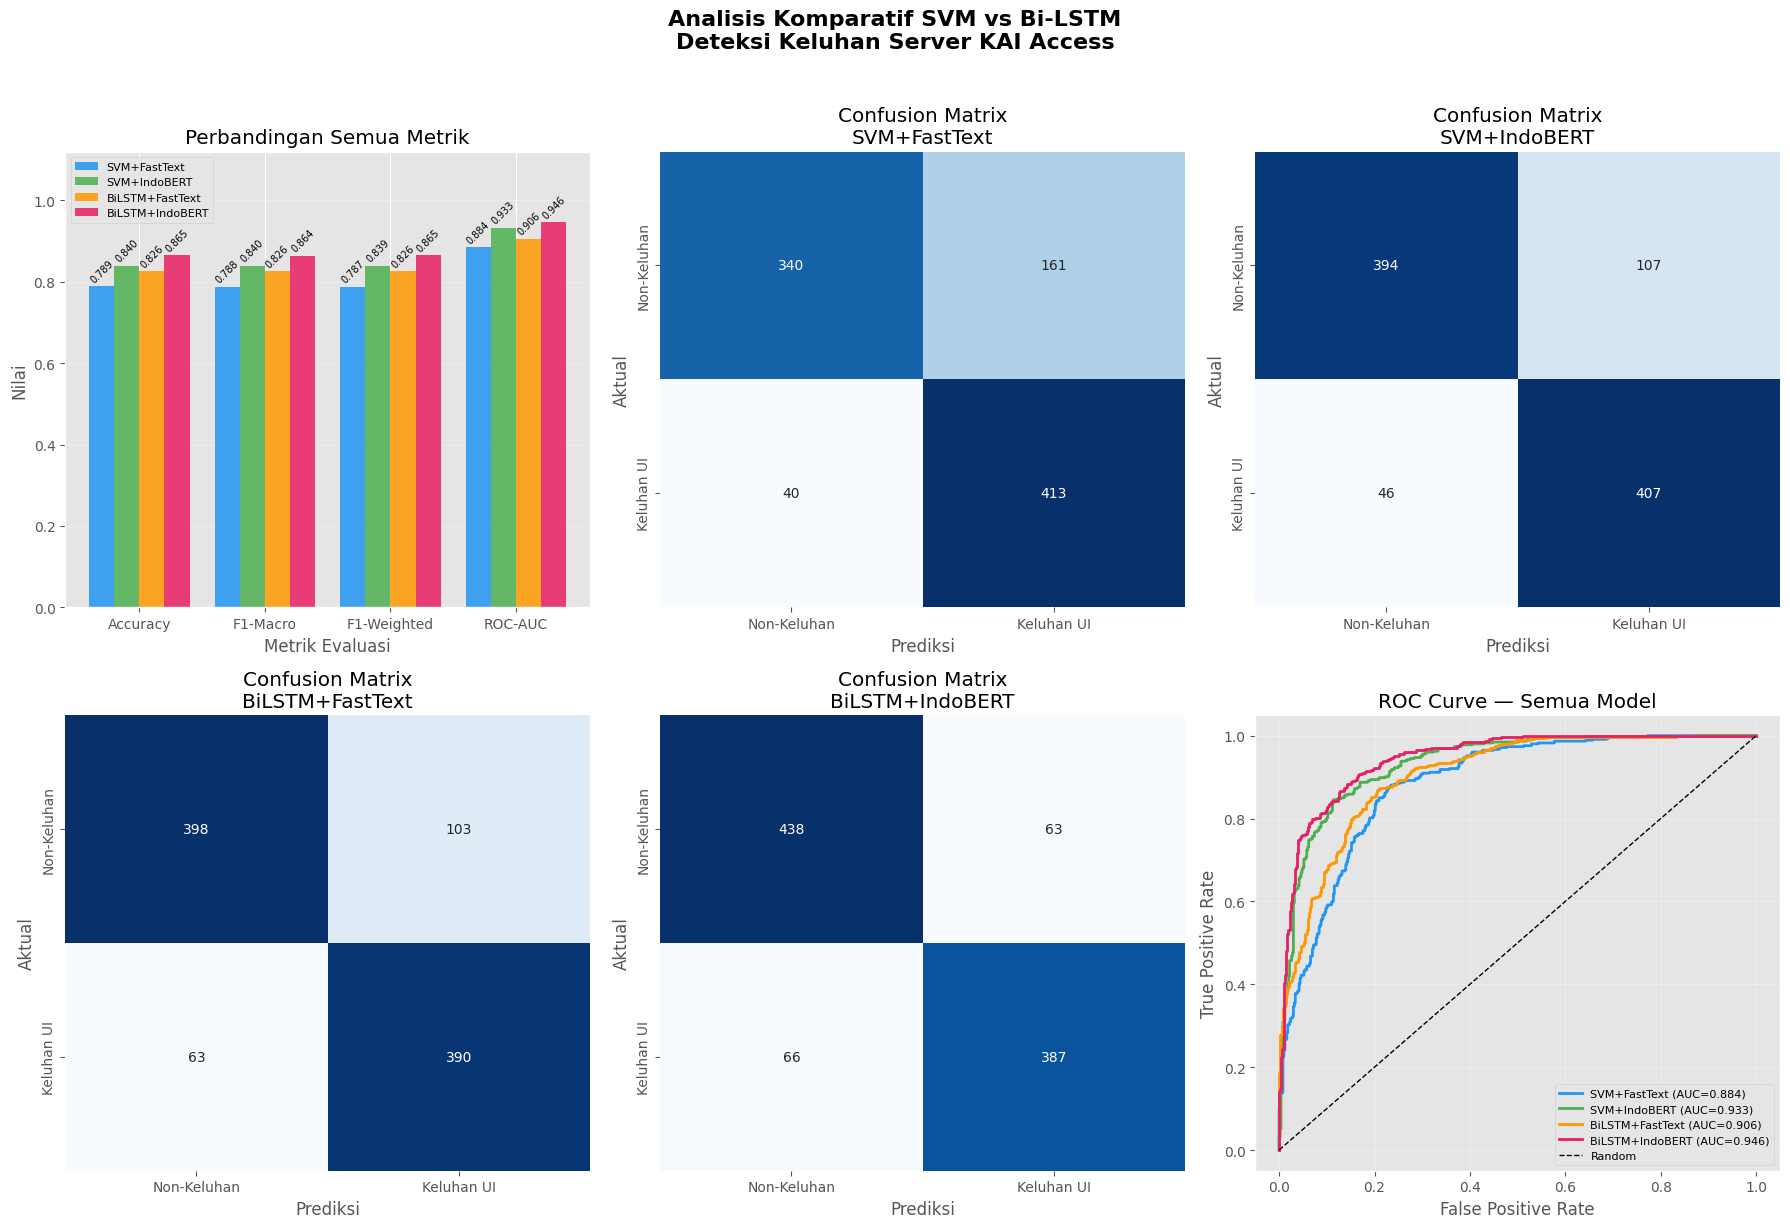

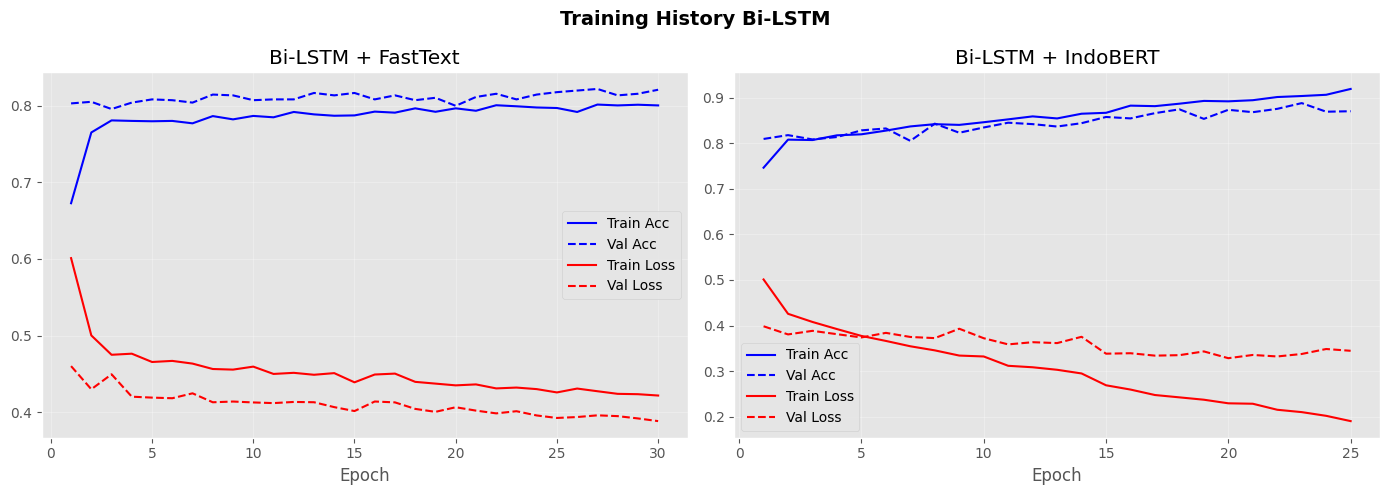

TABEL RINGKASAN PERBANDINGAN
          Model Accuracy F1-Macro F1-Weighted ROC-AUC
   SVM+FastText   0.7893   0.7881      0.7873  0.8844
   SVM+IndoBERT   0.8396   0.8396      0.8395  0.9327
BiLSTM+FastText   0.8260   0.8260      0.8261  0.9055
BiLSTM+IndoBERT   0.8648   0.8644      0.8648  0.9459

🏆 Model terbaik: BiLSTM+IndoBERT
   F1-Macro : 0.8644
   Accuracy : 0.8648
   ROC-AUC  : 0.9459


In [55]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

semua_hasil = [hasil_svm_ft, hasil_svm_ib, hasil_bilstm_ft, hasil_bilstm_ib]
nama_model  = [h['nama'] for h in semua_hasil]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Analisis Komparatif SVM vs Bi-LSTM\nDeteksi Keluhan Server KAI Access',
             fontsize=16, fontweight='bold', y=1.02)

# Bar chart perbandingan metrik
ax = axes[0, 0]
metrik = ['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']
label_metrik = ['Accuracy', 'F1-Macro', 'F1-Weighted', 'ROC-AUC']
x = np.arange(len(metrik))
width = 0.2
warna = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (h, w) in enumerate(zip(semua_hasil, warna)):
    nilai = [h[m] for m in metrik]
    bars = ax.bar(x + i * width - 1.5 * width, nilai, width, label=h['nama'], color=w, alpha=0.85)
    for bar, val in zip(bars, nilai):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xlabel('Metrik Evaluasi')
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Semua Metrik')
ax.set_xticks(x)
ax.set_xticklabels(label_metrik)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Confusion Matrix
posisi_cm = [(0, 1), (0, 2), (1, 0), (1, 1)]
for i, (h, pos) in enumerate(zip(semua_hasil, posisi_cm)):
    ax = axes[pos]
    cm = h['cm']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Non-Keluhan', 'Keluhan UI'],
        yticklabels=['Non-Keluhan', 'Keluhan UI'],
        ax=ax, cbar=False
    )
    ax.set_title(f'Confusion Matrix\n{h["nama"]}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

# ROC Curve
ax = axes[1, 2]
for h, w in zip(semua_hasil, warna):
    fpr, tpr, _ = roc_curve(y_test, h['y_prob'])
    ax.plot(fpr, tpr, color=w, linewidth=2,
            label=f"{h['nama']} (AUC={h['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Semua Model')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hasil_perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

# Training history Bi-LSTM
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Training History Bi-LSTM', fontsize=14, fontweight='bold')

for ax, h, judul in zip(axes2,
                         [hasil_bilstm_ft, hasil_bilstm_ib],
                         ['Bi-LSTM + FastText', 'Bi-LSTM + IndoBERT']):
    hist = h['history'].history
    epoch = range(1, len(hist['accuracy']) + 1)
    ax.plot(epoch, hist['accuracy'],     'b-', label='Train Acc')
    ax.plot(epoch, hist['val_accuracy'], 'b--', label='Val Acc')
    ax.plot(epoch, hist['loss'],         'r-', label='Train Loss')
    ax.plot(epoch, hist['val_loss'],     'r--', label='Val Loss')
    ax.set_title(judul)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_bilstm.png', dpi=150, bbox_inches='tight')
plt.show()


print("TABEL RINGKASAN PERBANDINGAN")

df_ringkasan = pd.DataFrame([
    {
        'Model': h['nama'],
        'Accuracy': f"{h['accuracy']:.4f}",
        'F1-Macro': f"{h['f1_macro']:.4f}",
        'F1-Weighted': f"{h['f1_weighted']:.4f}",
        'ROC-AUC': f"{h['roc_auc']:.4f}"
    }
    for h in semua_hasil
])

print(df_ringkasan.to_string(index=False))

idx_terbaik  = np.argmax([h['f1_macro'] for h in semua_hasil])
model_terbaik = semua_hasil[idx_terbaik]
print(f"\n🏆 Model terbaik: {model_terbaik['nama']}")
print(f"   F1-Macro : {model_terbaik['f1_macro']:.4f}")
print(f"   Accuracy : {model_terbaik['accuracy']:.4f}")
print(f"   ROC-AUC  : {model_terbaik['roc_auc']:.4f}")

df_ringkasan.to_csv('ringkasan_hasil_model.csv', index=False)

## **Meningkatkan Akurasi**

### Hyperparameter Tuning SVM

In [47]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time
 
# ML & tuning
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
 
# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW  
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Bidirectional, LSTM, Dense, Dropout,
                                      Embedding, Input, BatchNormalization,
                                      Attention, LayerNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
 
# Optuna untuk tuning Bi-LSTM
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
except ImportError:
    print("⚠️  Optuna tidak tersedia. Install: pip install optuna")
    OPTUNA_OK = False
 
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# Gabungkan train+val untuk cross-validation
X_trainval    = np.concatenate([X_train, X_val])
y_trainval    = np.concatenate([y_train, y_val])
X_trainval_ft = np.vstack([X_train_ft, X_val_ft])
X_trainval_ib = np.vstack([X_train_ib, X_val_ib])
 
print(f"   Train+Val : {len(X_trainval)} sampel")
print(f"   Test      : {len(X_test)} sampel")

   Train+Val : 5406 sampel
   Test      : 954 sampel



─── Tuning SVM + FastText
   Total kombinasi: 32 × 5-fold CV
   Selesai dalam 509.8 detik
   Parameter terbaik : {'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
   CV F1-Macro terbaik: 0.8821

   Hasil pada TEST SET:
      Accuracy     : 0.9099
      F1 (macro)   : 0.9098
      F1 (weighted): 0.9099
      ROC-AUC      : 0.9535
                    precision    recall  f1-score   support

Non-Keluhan Server       0.93      0.89      0.91       501
    Keluhan Server       0.89      0.93      0.91       453

          accuracy                           0.91       954
         macro avg       0.91      0.91      0.91       954
      weighted avg       0.91      0.91      0.91       954


─── Tuning SVM + IndoBERT
   Total kombinasi: 32 × 5-fold CV
   Selesai dalam 3479.7 detik
   Parameter terbaik : {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
   CV F1-Macro terbaik: 0.9333

   Hasil pada TEST SET:
      Accuracy     : 0.9686
      F1 (macro)   : 0.9685
      F

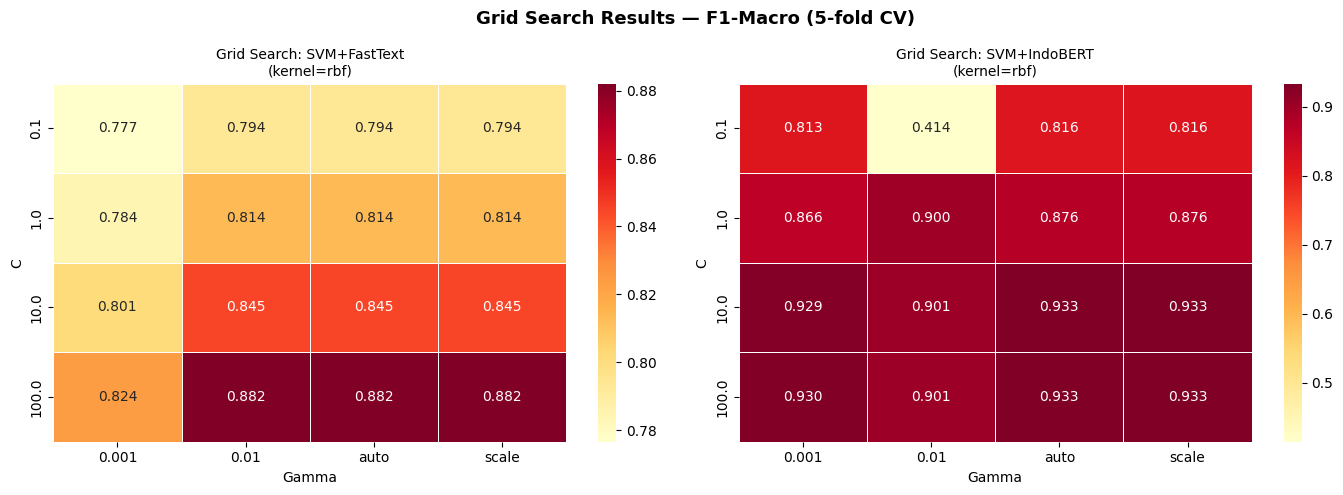

In [49]:
param_grid_svm = {
    'svc__C':      [0.1, 1, 10, 100],
    'svc__gamma':  ['scale', 'auto', 0.001, 0.01],
    'svc__kernel': ['rbf', 'sigmoid'],
}

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(probability=True, class_weight='balanced', random_state=42))
])

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tuning_svm(X_tr, y_tr, X_te, y_te, nama_fitur):
    print(f"\n─── Tuning SVM + {nama_fitur}")
    print(f"   Total kombinasi: {len(param_grid_svm['svc__C']) * len(param_grid_svm['svc__gamma']) * len(param_grid_svm['svc__kernel'])} × 5-fold CV")

    grid_search = GridSearchCV(
        estimator=pipeline_svm,
        param_grid=param_grid_svm,
        cv=cv_inner,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0,
        refit=True
    )

    t0 = time.time()
    grid_search.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    print(f"   Selesai dalam {elapsed:.1f} detik")
    print(f"   Parameter terbaik : {grid_search.best_params_}")
    print(f"   CV F1-Macro terbaik: {grid_search.best_score_:.4f}")

    # Evaluasi pada test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_te)
    y_prob = best_model.predict_proba(X_te)[:, 1]

    acc    = accuracy_score(y_te, y_pred)
    f1_mac = f1_score(y_te, y_pred, average='macro')
    f1_wei = f1_score(y_te, y_pred, average='weighted')
    auc    = roc_auc_score(y_te, y_prob)

    print(f"\n   Hasil pada TEST SET:")
    print(f"      Accuracy     : {acc:.4f}")
    print(f"      F1 (macro)   : {f1_mac:.4f}")
    print(f"      F1 (weighted): {f1_wei:.4f}")
    print(f"      ROC-AUC      : {auc:.4f}")
    print(classification_report(y_te, y_pred, target_names=['Non-Keluhan Server', 'Keluhan Server']))

    return {
        'nama': f'SVM+{nama_fitur} (Tuned)',
        'model': best_model,
        'best_params': grid_search.best_params_,
        'cv_score': grid_search.best_score_,
        'accuracy': acc, 'f1_macro': f1_mac,
        'f1_weighted': f1_wei, 'roc_auc': auc,
        'y_pred': y_pred, 'y_prob': y_prob,
        'cm': confusion_matrix(y_te, y_pred),
        'grid_search': grid_search
    }

hasil_svm_ft_tuned = tuning_svm(X_trainval_ft, y_trainval, X_test_ft, y_test, 'FastText')
hasil_svm_ib_tuned = tuning_svm(X_trainval_ib, y_trainval, X_test_ib, y_test, 'IndoBERT')


# Heatmap hasil grid search
def plot_gridsearch_heatmap(grid_search, nama_fitur, ax):
    results = pd.DataFrame(grid_search.cv_results_)

    for kernel in ['rbf', 'sigmoid']:
        mask = results['param_svc__kernel'] == kernel
        subset = results[mask].pivot_table(
            index='param_svc__C',
            columns='param_svc__gamma',
            values='mean_test_score'
        )
        sns.heatmap(
            subset.astype(float), annot=True, fmt='.3f',
            cmap='YlOrRd', ax=ax, cbar=True,
            linewidths=0.5
        )
        ax.set_title(f'Grid Search: SVM+{nama_fitur}\n(kernel={kernel})', fontsize=10)
        ax.set_xlabel('Gamma')
        ax.set_ylabel('C')
        break   

fig_gs, axes_gs = plt.subplots(1, 2, figsize=(14, 5))
fig_gs.suptitle('Grid Search Results — F1-Macro (5-fold CV)', fontsize=13, fontweight='bold')
plot_gridsearch_heatmap(hasil_svm_ft_tuned['grid_search'], 'FastText', axes_gs[0])
plot_gridsearch_heatmap(hasil_svm_ib_tuned['grid_search'], 'IndoBERT', axes_gs[1])
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### K-Fold Cross Validation

STRATIFIED K-FOLD CROSS-VALIDATION (10-fold)

─── CV 10-fold: SVM+FastText (Tuned)
   Fold  1: Acc=0.8799 | F1=0.8797 | AUC=0.9389
   Fold  2: Acc=0.8928 | F1=0.8926 | AUC=0.9434
   Fold  3: Acc=0.8706 | F1=0.8704 | AUC=0.9360
   Fold  4: Acc=0.8725 | F1=0.8724 | AUC=0.9348
   Fold  5: Acc=0.9094 | F1=0.9093 | AUC=0.9565
   Fold  6: Acc=0.9039 | F1=0.9039 | AUC=0.9618
   Fold  7: Acc=0.8944 | F1=0.8944 | AUC=0.9488
   Fold  8: Acc=0.8889 | F1=0.8889 | AUC=0.9348
   Fold  9: Acc=0.9130 | F1=0.9129 | AUC=0.9602
   Fold 10: Acc=0.8870 | F1=0.8869 | AUC=0.9220

    Ringkasan 10-fold:
      Accuracy    : 0.8912 ± 0.0138
      F1-Macro    : 0.8911 ± 0.0138
      F1-Weighted : 0.8913 ± 0.0138
      ROC-AUC     : 0.9437 ± 0.0123

─── CV 10-fold: SVM+IndoBERT (Tuned)
   Fold  1: Acc=0.9575 | F1=0.9574 | AUC=0.9827
   Fold  2: Acc=0.9501 | F1=0.9500 | AUC=0.9857
   Fold  3: Acc=0.9390 | F1=0.9388 | AUC=0.9727
   Fold  4: Acc=0.9593 | F1=0.9593 | AUC=0.9923
   Fold  5: Acc=0.9556 | F1=0.9555 | AU

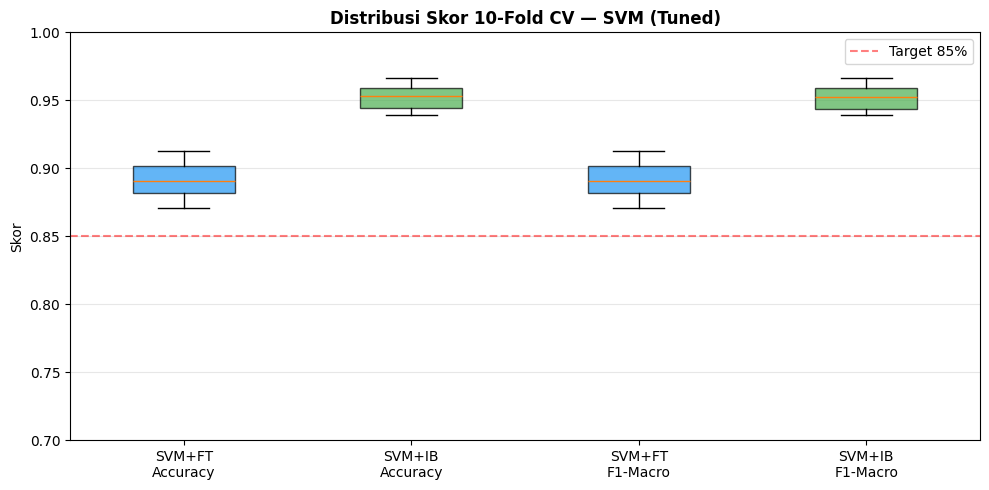

In [50]:
print("STRATIFIED K-FOLD CROSS-VALIDATION (10-fold)")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def cross_validate_model(model_fn, X, y, nama_model, is_keras=False):
    print(f"\n─── CV 10-fold: {nama_model}")

    scores_acc, scores_f1mac, scores_f1wei, scores_auc = [], [], [], []
    cb = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_v = X[tr_idx], X[val_idx]
        y_tr, y_v = y[tr_idx], y[val_idx]

        model = model_fn()

        if is_keras:
            model.fit(
                X_tr, y_tr,
                validation_data=(X_v, y_v),
                epochs=20, batch_size=64,
                callbacks=cb, verbose=0
            )
            y_prob = model.predict(X_v, verbose=0).flatten()
            y_pred = (y_prob >= 0.5).astype(int)
        else:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_v)
            y_prob = model.predict_proba(X_v)[:, 1]

        scores_acc.append(accuracy_score(y_v, y_pred))
        scores_f1mac.append(f1_score(y_v, y_pred, average='macro'))
        scores_f1wei.append(f1_score(y_v, y_pred, average='weighted'))
        scores_auc.append(roc_auc_score(y_v, y_prob))

        print(f"   Fold {fold:2d}: Acc={scores_acc[-1]:.4f} | "
              f"F1={scores_f1mac[-1]:.4f} | AUC={scores_auc[-1]:.4f}")

    print(f"\n    Ringkasan 10-fold:")
    for nama_s, vals in [('Accuracy', scores_acc), ('F1-Macro', scores_f1mac),
                          ('F1-Weighted', scores_f1wei), ('ROC-AUC', scores_auc)]:
        print(f"      {nama_s:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

    return {
        'nama': nama_model,
        'acc': np.array(scores_acc),
        'f1_macro': np.array(scores_f1mac),
        'f1_weighted': np.array(scores_f1wei),
        'auc': np.array(scores_auc),
    }

# ── CV untuk SVM terbaik (gunakan parameter hasil tuning) 
best_C_ft     = hasil_svm_ft_tuned['best_params']['svc__C']
best_gamma_ft = hasil_svm_ft_tuned['best_params']['svc__gamma']
best_C_ib     = hasil_svm_ib_tuned['best_params']['svc__C']
best_gamma_ib = hasil_svm_ib_tuned['best_params']['svc__gamma']

def buat_svm_ft():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(C=best_C_ft, gamma=best_gamma_ft, kernel='rbf',
                    probability=True, class_weight='balanced', random_state=42))
    ])

def buat_svm_ib():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(C=best_C_ib, gamma=best_gamma_ib, kernel='rbf',
                    probability=True, class_weight='balanced', random_state=42))
    ])

cv_svm_ft = cross_validate_model(buat_svm_ft, X_trainval_ft, y_trainval, 'SVM+FastText (Tuned)')
cv_svm_ib = cross_validate_model(buat_svm_ib, X_trainval_ib, y_trainval, 'SVM+IndoBERT (Tuned)')

# ── Visualisasi CV boxplot
fig_cv, ax_cv = plt.subplots(figsize=(10, 5))
data_box = {
    'SVM+FT\nAccuracy':  cv_svm_ft['acc'],
    'SVM+IB\nAccuracy':  cv_svm_ib['acc'],
    'SVM+FT\nF1-Macro':  cv_svm_ft['f1_macro'],
    'SVM+IB\nF1-Macro':  cv_svm_ib['f1_macro'],
}
bp = ax_cv.boxplot(data_box.values(), labels=data_box.keys(),
                   patch_artist=True, notch=False)
colors = ['#2196F3', '#4CAF50', '#2196F3', '#4CAF50']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax_cv.set_title('Distribusi Skor 10-Fold CV — SVM (Tuned)', fontsize=12, fontweight='bold')
ax_cv.set_ylabel('Skor')
ax_cv.set_ylim(0.7, 1.0)
ax_cv.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target 85%')
ax_cv.grid(axis='y', alpha=0.3)
ax_cv.legend()
plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### Hyperparameter Tuning Bi-LSTM

Best trial: 24. Best value: 0.896224: 100%|██████████| 30/30 [13:20<00:00, 26.68s/it]



 Trial terbaik: #24
   F1-Macro (val): 0.8962
   Parameter optimal:
      lstm_units_1: 64
      lstm_units_2: 64
      dense_units: 128
      dropout_1: 0.1
      dropout_2: 0.1
      lr: 0.0003810105687483449
      batch_size: 64
Epoch 1/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7644 - loss: 0.4677 - val_accuracy: 0.7726 - val_loss: 0.5388
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8282 - loss: 0.3766 - val_accuracy: 0.8059 - val_loss: 0.4652
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8458 - loss: 0.3403 - val_accuracy: 0.8373 - val_loss: 0.4146
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8598 - loss: 0.3067 - val_accuracy: 0.8429 - val_loss: 0.3657
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8781 - loss: 0.2788 - val_accuracy: 0.8318 - val_loss: 0.3708
Epoch 6/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8857 - loss: 0.2481 - val_accuracy: 0.8614 - val_loss: 0.3308
Epoch

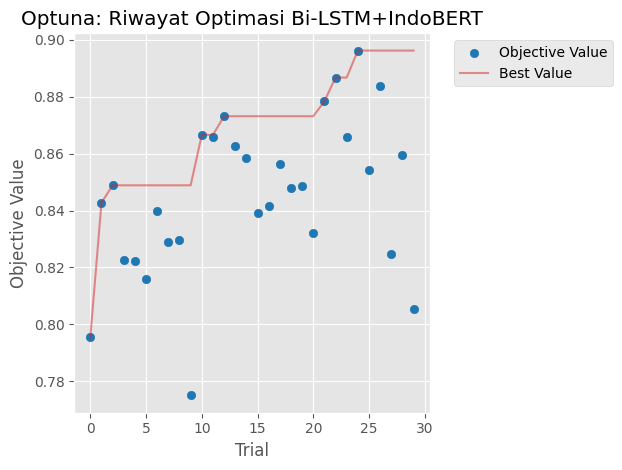

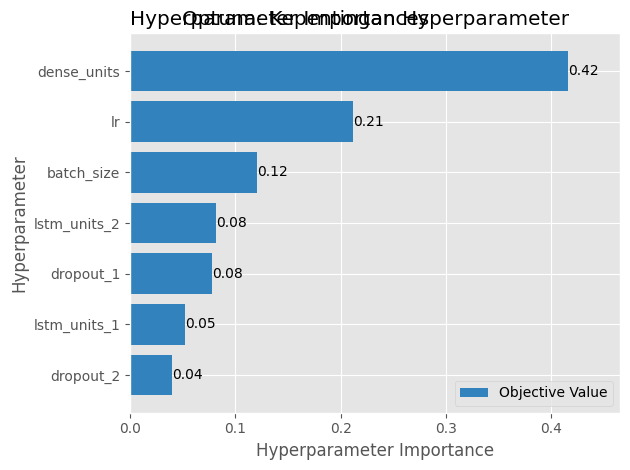

In [51]:
import numpy as np
import optuna
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

X_train_ib3d    = np.asarray(X_train_ib.reshape(-1, 1, 768)).astype(np.float32)
X_val_ib3d      = np.asarray(X_val_ib.reshape(-1, 1, 768)).astype(np.float32)
X_test_ib3d     = np.asarray(X_test_ib.reshape(-1, 1, 768)).astype(np.float32)
X_trainval_ib3d = np.asarray(X_trainval_ib.reshape(-1, 1, 768)).astype(np.float32)

y_train_np      = np.asarray(y_train).astype(np.float32)
y_val_np        = np.asarray(y_val).astype(np.float32)
y_test_np       = np.asarray(y_test).astype(np.float32)
y_trainval_np   = np.asarray(y_trainval).astype(np.float32)

OPTUNA_OK = True 

if OPTUNA_OK:
    def objective_bilstm(trial):
        lstm_units_1 = trial.suggest_categorical('lstm_units_1', [64, 128, 256])
        lstm_units_2 = trial.suggest_categorical('lstm_units_2', [32, 64, 128])
        dense_units  = trial.suggest_categorical('dense_units',  [32, 64, 128])
        dropout_1    = trial.suggest_float('dropout_1', 0.1, 0.5, step=0.1)
        dropout_2    = trial.suggest_float('dropout_2', 0.1, 0.5, step=0.1)
        lr           = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        batch_size   = trial.suggest_categorical('batch_size', [32, 64, 128])

        inp = Input(shape=(1, 768))
        x   = Bidirectional(LSTM(lstm_units_1, return_sequences=False,
                                 dropout=dropout_1))(inp)
        x   = BatchNormalization()(x)
        x   = Dense(dense_units, activation='relu')(x)
        x   = Dropout(dropout_2)(x)
        if lstm_units_2 > 0:
            x = Dense(lstm_units_2, activation='relu')(x)
            x = Dropout(dropout_2 * 0.5)(x)
        out = Dense(1, activation='sigmoid')(x)

        model = Model(inputs=inp, outputs=out)
        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        class F1MacroCallback(tf.keras.callbacks.Callback):
            def on_epoch_end(self, epoch, logs=None):
                y_prob = self.model.predict(X_val_ib3d, verbose=0).flatten()
                y_pred = (y_prob >= 0.5).astype(int)
                logs['val_f1_macro'] = f1_score(y_val_np, y_pred, average='macro')

        history = model.fit(
            X_train_ib3d, y_train_np,
            validation_data=(X_val_ib3d, y_val_np),
            epochs=15, batch_size=batch_size,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
                F1MacroCallback()
            ],
            verbose=0
        )

        y_prob_val = model.predict(X_val_ib3d, verbose=0).flatten()
        y_pred_val = (y_prob_val >= 0.5).astype(int)
        return f1_score(y_val_np, y_pred_val, average='macro')

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_bilstm, n_trials=30, show_progress_bar=True)

    best_trial = study.best_trial
    print(f"\n Trial terbaik: #{best_trial.number}")
    print(f"   F1-Macro (val): {best_trial.value:.4f}")
    print(f"   Parameter optimal:")
    for k, v in best_trial.params.items():
        print(f"      {k}: {v}")

    bp = best_trial.params
    inp = Input(shape=(1, 768))
    x   = Bidirectional(LSTM(bp['lstm_units_1'], return_sequences=False,
                             dropout=bp['dropout_1']))(inp)
    x   = BatchNormalization()(x)
    x   = Dense(bp['dense_units'], activation='relu')(x)
    x   = Dropout(bp['dropout_2'])(x)
    x   = Dense(bp['lstm_units_2'], activation='relu')(x)
    x   = Dropout(bp['dropout_2'] * 0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    bilstm_ib_tuned = Model(inputs=inp, outputs=out)
    bilstm_ib_tuned.compile(
        optimizer=Adam(learning_rate=bp['lr']),
        loss='binary_crossentropy', metrics=['accuracy']
    )

    bilstm_ib_tuned.fit(
        X_trainval_ib3d, y_trainval_np,
        validation_split=0.1,
        epochs=30, batch_size=bp['batch_size'],
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    # Evaluasi
    y_prob_tuned = bilstm_ib_tuned.predict(X_test_ib3d, verbose=0).flatten()
    y_pred_tuned = (y_prob_tuned >= 0.5).astype(int)

    acc_t    = accuracy_score(y_test_np, y_pred_tuned)
    f1_mac_t = f1_score(y_test_np, y_pred_tuned, average='macro')
    f1_wei_t = f1_score(y_test_np, y_pred_tuned, average='weighted')
    auc_t    = roc_auc_score(y_test_np, y_prob_tuned)

    print(f"\n Bi-LSTM+IndoBERT TUNED — Test Set:")
    print(f"   Accuracy     : {acc_t:.4f}")
    print(f"   F1 (macro)   : {f1_mac_t:.4f}")
    print(f"   ROC-AUC      : {auc_t:.4f}")
    print(classification_report(y_test_np, y_pred_tuned, target_names=['Non-Keluhan Server', 'Keluhan Server']))

    hasil_bilstm_ib_tuned = {
        'nama': 'BiLSTM+IndoBERT (Tuned)',
        'accuracy': acc_t, 'f1_macro': f1_mac_t,
        'f1_weighted': f1_wei_t, 'roc_auc': auc_t,
        'y_pred': y_pred_tuned, 'y_prob': y_prob_tuned,
        'cm': confusion_matrix(y_test_np, y_pred_tuned)
    }

    # Optuna visualization
    try:
        fig_opt = optuna.visualization.matplotlib.plot_optimization_history(study)
        plt.title('Optuna: Riwayat Optimasi Bi-LSTM+IndoBERT')
        plt.tight_layout()
        plt.savefig('optuna_history.png', dpi=150, bbox_inches='tight')
        plt.show()

        fig_imp = optuna.visualization.matplotlib.plot_param_importances(study)
        plt.title('Optuna: Kepentingan Hyperparameter')
        plt.tight_layout()
        plt.savefig('optuna_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f" Grafik Optuna tidak bisa dibuat: {e}")

In [52]:
import numpy as np
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

print("TUNING HYPERPARAMETER — Bi-LSTM + FastText (Optuna)")

if OPTUNA_OK:
    def objective_bilstm_ft(trial):
        lstm_units = trial.suggest_categorical('lstm_units', [32, 64, 128])
        dropout_1  = trial.suggest_float('dropout_1', 0.2, 0.6, step=0.1)
        dropout_2  = trial.suggest_float('dropout_2', 0.2, 0.5, step=0.1)
        lr         = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
        batch_size = trial.suggest_categorical('batch_size', [32, 64])

        model = Sequential([
            Embedding(
                input_dim=embedding_matrix.shape[0],
                output_dim=EMBED_DIM, 
                weights=[embedding_matrix],
                input_length=MAX_LEN, 
                trainable=False
            ),
            Bidirectional(LSTM(lstm_units, return_sequences=True, dropout=dropout_1)),
            Bidirectional(LSTM(int(lstm_units/2), dropout=dropout_1)),
            Dense(64, activation='relu'),
            Dropout(dropout_2),
            Dense(1, activation='sigmoid')
        ])

        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        class F1MacroCallbackFT(tf.keras.callbacks.Callback):
            def on_epoch_end(self, epoch, logs=None):
                y_prob = self.model.predict(X_val_seq, verbose=0).flatten()
                y_pred = (y_prob >= 0.5).astype(int)
                logs['val_f1_macro'] = f1_score(y_val_np, y_pred, average='macro')

        model.fit(
            X_train_seq, y_train_np,
            validation_data=(X_val_seq, y_val_np),
            epochs=15, 
            batch_size=batch_size,
            callbacks=[
                EarlyStopping(monitor='val_f1_macro', patience=4, mode='max', restore_best_weights=True),
                F1MacroCallbackFT()
            ],
            verbose=0
        )

        y_prob_val = model.predict(X_val_seq, verbose=0).flatten()
        y_pred_val = (y_prob_val >= 0.5).astype(int)
        return f1_score(y_val_np, y_pred_val, average='macro')

    study_ft = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study_ft.optimize(objective_bilstm_ft, n_trials=20, show_progress_bar=True) 

    best_bp = study_ft.best_trial.params
    print(f"\n Parameter optimal Bi-LSTM + FastText:")
    for k, v in best_bp.items():
        print(f"      {k}: {v}")

    bilstm_ft_tuned = Sequential([
        Embedding(input_dim=embedding_matrix.shape[0], output_dim=EMBED_DIM,
                  weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
        Bidirectional(LSTM(best_bp['lstm_units'], return_sequences=True, dropout=best_bp['dropout_1'])),
        Bidirectional(LSTM(int(best_bp['lstm_units']/2), dropout=best_bp['dropout_1'])),
        Dense(64, activation='relu'),
        Dropout(best_bp['dropout_2']),
        Dense(1, activation='sigmoid')
    ])
    
    bilstm_ft_tuned.compile(optimizer=Adam(learning_rate=best_bp['lr']), loss='binary_crossentropy', metrics=['accuracy'])
    
    X_trainval_seq = np.vstack((X_train_seq, X_val_seq))
    y_trainval_np = np.concatenate((y_train_np, y_val_np))

    bilstm_ft_tuned.fit(
        X_trainval_seq, y_trainval_np,
        validation_split=0.1,
        epochs=30, batch_size=best_bp['batch_size'],
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    y_prob_tuned_ft = bilstm_ft_tuned.predict(X_test_seq, verbose=0).flatten()
    y_pred_tuned_ft = (y_prob_tuned_ft >= 0.5).astype(int)

    acc_t_ft    = accuracy_score(y_test_np, y_pred_tuned_ft)
    f1_mac_t_ft = f1_score(y_test_np, y_pred_tuned_ft, average='macro')
    f1_wei_t_ft = f1_score(y_test_np, y_pred_tuned_ft, average='weighted')
    auc_t_ft    = roc_auc_score(y_test_np, y_prob_tuned_ft)

    print(f"\n Bi-LSTM+FastText TUNED — Test Set:")
    print(f"   Accuracy     : {acc_t_ft:.4f}")
    print(f"   F1 (macro)   : {f1_mac_t_ft:.4f}")
    print(f"   ROC-AUC      : {auc_t_ft:.4f}")

    hasil_bilstm_ft_tuned = {
        'nama': 'BiLSTM+FastText (Tuned)',
        'accuracy': acc_t_ft, 'f1_macro': f1_mac_t_ft,
        'f1_weighted': f1_wei_t_ft, 'roc_auc': auc_t_ft, 
        'y_pred': y_pred_tuned_ft, 'y_prob': y_prob_tuned_ft,
        'cm': confusion_matrix(y_test_np, y_pred_tuned_ft)
    }

TUNING HYPERPARAMETER — Bi-LSTM + FastText (Optuna)


  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 16. Best value: 0.820485: 100%|██████████| 20/20 [1:10:53<00:00, 212.68s/it]


 Parameter optimal Bi-LSTM + FastText:
      lstm_units: 32
      dropout_1: 0.30000000000000004
      dropout_2: 0.2
      lr: 0.0012618656869265743
      batch_size: 32
Epoch 1/30


153/153 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.7168 - loss: 0.5513 - val_accuracy: 0.7856 - val_loss: 0.4539
Epoch 2/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.7675 - loss: 0.4860 - val_accuracy: 0.7763 - val_loss: 0.4419
Epoch 3/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.7807 - loss: 0.4680 - val_accuracy: 0.7800 - val_loss: 0.4433
Epoch 4/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.7799 - loss: 0.4609 - val_accuracy: 0.7726 - val_loss: 0.4360
Epoch 5/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.7825 - loss: 0.4552 - val_accuracy: 0.7708 - val_loss: 0.4475
Epoch 6/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.7895 - loss: 0.4487 - val_accuracy: 0.7763 - val_loss: 0.4311
Epoch 7/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.7897 - loss: 0.4457 - val_accuracy: 0.7800 - val_loss: 0.4278
Epoch 8/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.7868 - loss: 0.4506 - val_accurac

### Ringkasan

RINGKASAN FINAL — SEMUA MODEL (BASELINE vs IMPROVED)
                  Model     Type  Accuracy  F1-Macro  ROC-AUC
   SVM+IndoBERT (Tuned) Improved  0.968553  0.968480 0.996660
   SVM+FastText (Tuned) Improved  0.909853  0.909776 0.953504
BiLSTM+IndoBERT (Tuned) Improved  0.887841  0.887813 0.955304
        BiLSTM+IndoBERT Baseline  0.864780  0.864392 0.945857
           SVM+IndoBERT Baseline  0.839623  0.839593 0.932700
        BiLSTM+FastText Baseline  0.825996  0.825984 0.905505
BiLSTM+FastText (Tuned) Improved  0.820755  0.820668 0.913396
           SVM+FastText Baseline  0.789308  0.788067 0.884366


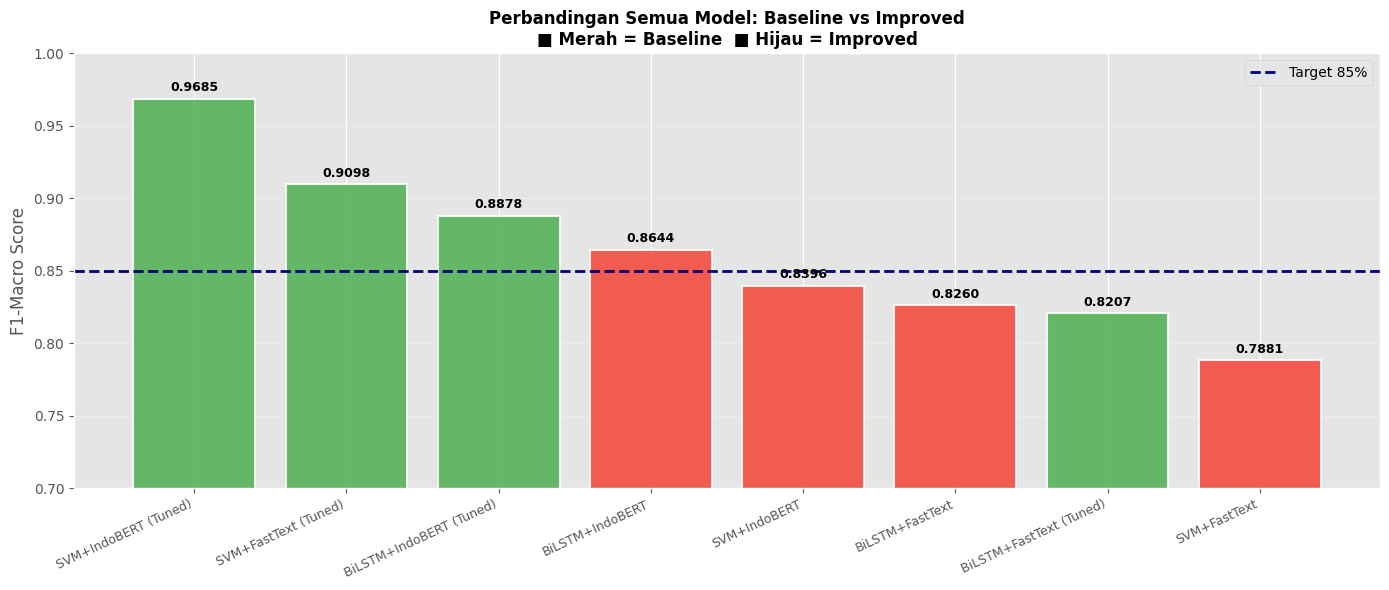

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("RINGKASAN FINAL — SEMUA MODEL (BASELINE vs IMPROVED)")

baseline = [
    hasil_svm_ft,
    hasil_svm_ib,
    hasil_bilstm_ft,
    hasil_bilstm_ib,
]

improved = [
    hasil_svm_ft_tuned,
    hasil_svm_ib_tuned,
    hasil_bilstm_ft_tuned,
]
if OPTUNA_OK and hasil_bilstm_ib_tuned is not None:
    improved.append(hasil_bilstm_ib_tuned)

semua_rows = []
for h in baseline:
    semua_rows.append({
        'Model':    h['nama'],
        'Type':     'Baseline',
        'Accuracy': h['accuracy'],
        'F1-Macro': h['f1_macro'],
        'ROC-AUC':  h['roc_auc']
    })
for h in improved:
    semua_rows.append({
        'Model':    h['nama'],
        'Type':     'Improved',
        'Accuracy': h['accuracy'],
        'F1-Macro': h['f1_macro'],
        'ROC-AUC':  h['roc_auc']
    })

df_final = pd.DataFrame(semua_rows)
df_final = df_final.sort_values('F1-Macro', ascending=False)

print(df_final.to_string(index=False))

fig_final, ax_final = plt.subplots(figsize=(14, 6))

x    = np.arange(len(df_final))
bars = ax_final.bar(x, df_final['F1-Macro'],
                    color=['#F44336' if t == 'Baseline' else '#4CAF50'
                           for t in df_final['Type']],
                    alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, df_final['F1-Macro']):
    ax_final.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                  f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_final.axhline(y=0.85, color='navy', linestyle='--', linewidth=2, label='Target 85%')
ax_final.set_xticks(x)
ax_final.set_xticklabels(df_final['Model'], rotation=25, ha='right', fontsize=9)
ax_final.set_ylabel('F1-Macro Score')
ax_final.set_title('Perbandingan Semua Model: Baseline vs Improved\n'
                   '■ Merah = Baseline  ■ Hijau = Improved', fontsize=12, fontweight='bold')
ax_final.set_ylim(0.7, 1.0)
ax_final.grid(axis='y', alpha=0.3)
ax_final.legend(fontsize=10)

plt.tight_layout()
plt.savefig('perbandingan_final.png', dpi=150, bbox_inches='tight')
plt.show()

df_final.to_csv('ringkasan_final_semua_model.csv', index=False)